# 2025 - 2학기 머신러닝 팀플 - 학습용(train)
## 주제. Colored MNIST classification

#### 팀명: 러닝머신 🏃
- 20211513 김동준
- 20211546 이채현 (조장 🙋)
- 20212996 허준범


# 코드 실행 전 랜덤 시드 고정 (재현성 보장)

In [1]:
import random
import os
import numpy as np

def seed_everything(seed=42):
    # 1. Python 내장 random 모듈
    random.seed(seed)

    # 2. OS 환경변수 (해시 함수 등의 무작위성 제어)
    os.environ['PYTHONHASHSEED'] = str(seed)

    # 3. NumPy
    np.random.seed(seed)

    # 4. CuPy (설치되어 있는 경우)
    try:
        import cupy as cp
        cp.random.seed(seed)
    except ImportError:
        pass  # cupy가 설치되지 않은 환경에서는 무시

    print(f"Random seed set to {seed}")

# 사용 예시
seed_everything(42)

Random seed set to 42


In [2]:
import numpy as np
import gc

IS_BW       = True
USE_CUML    = True

# 저장했던 .npz 파일 불러오기
if IS_BW:
    mnist_train = np.load('../data/BW_images.npz', allow_pickle=True)
else:
    mnist_train = np.load('../data/datas.npz', allow_pickle=True)

# 파일에 어떤 키들이 저장되어 있는지 확인
print("\n파일에 저장된 키 목록:", list(mnist_train.keys()))

for key in mnist_train.keys():
    print(f"{key}: {mnist_train[key].shape}")


파일에 저장된 키 목록: ['digit', 'filename', 'font', 'images']
digit: (120000,)
filename: (120000,)
font: (120000,)
images: (120000, 28, 28)


In [3]:
from sklearn.preprocessing import LabelEncoder

# 저장할 때 부여했던 이름(키)으로 각 배열에 접근

# MY_LABEL = 'foreground'
# MY_LABEL = 'background'
MY_LABEL = 'digit'

mnist_images = mnist_train['images'][60000:]
mnist_labels = mnist_train[MY_LABEL][60000:]
font_images = mnist_train['images'][:60000]
font_labels = mnist_train['digit'][:60000]

# transform type to int32
le = LabelEncoder()
mnist_labels = le.fit_transform(mnist_labels).astype(np.int32)

# reshape font data
if IS_BW:
    mnist_images = mnist_images.reshape(-1, 28*28).astype(np.float32)
    font_images = font_images.reshape(-1, 28*28).astype(np.float32)
    # flip data
    # mnist_images  = np.ones_like(mnist_images) * 255 - mnist_images
    # font_images   = np.ones_like(font_images) * 255 - font_images
else:
    mnist_images = mnist_images.reshape(-1, 28*28*3)
    font_images = font_images.reshape(-1, 28*28*3)


print("불러온 데이터 확인:")
print(f"학습용 이미지 shape: {mnist_images.shape}")
print(f"학습용 라벨 shape: {mnist_labels.shape}")

불러온 데이터 확인:
학습용 이미지 shape: (60000, 784)
학습용 라벨 shape: (60000,)


In [4]:
from sklearn.model_selection import train_test_split

# 1. 전체 데이터를 훈련 세트와 테스트 세트로 나눕니다. (80% 훈련, 20% 테스트)
train_input, val_input, train_target, val_target\
      = train_test_split(mnist_images, mnist_labels, test_size=0.2, random_state=42)

print("데이터 분할 후 shape:")
print(f"훈련 데이터: {train_input.shape}")
print(f"테스트 데이터: {val_input.shape}")

데이터 분할 후 shape:
훈련 데이터: (48000, 784)
테스트 데이터: (12000, 784)


# 모델 불러오기

In [5]:
import sys
try:
    # # to block
    if USE_CUML == True:
        if(train_input.shape[0] < 2500):
            print("train data가 작아 GPU사용을 스킵합니다.")
            raise ImportError('train data too small to use GPU')
        # Try to import cuml (for GPU acceleration)
        from cuml.neighbors import KNeighborsClassifier as cu_KNeighborsClassifier
        from cuml.ensemble import RandomForestClassifier as cu_RandomForestClassifier
        from cuml.multiclass import OneVsOneClassifier as cu_OneVsOneClassifier
        from cuml.svm import SVC as cu_SVC
        from cuml.linear_model import LogisticRegression as cu_LR
        import cupy as cp

        print("NVIDIA GPU detected. Using cuML for sClassifier.")
        SVC_class = cu_SVC()
        LR_class  = cu_LR()
        KNeighborsClassifier_class = cu_KNeighborsClassifier()
        RandomForestClassifier_class = cu_RandomForestClassifier(random_state=42)
        OneVsOneClassifier_svc_class = cu_OneVsOneClassifier(SVC_class)
        OneVsOneClassifier_lr_class = cu_OneVsOneClassifier(LR_class)
        USE_CUML = True

        train_input_cp      = cp.asarray(train_input)
        train_target_cp     = cp.asarray(train_target)

        val_input_cp       = cp.asarray(val_input)
        # val_target_cp      = cp.asarray(val_target)

    else:
        raise ImportError('user doesnt want to use GPU')

except ImportError as v:
    print(v)
    print("Using scikit-learn for Classifier.")
    USE_CUML = False
    # Fallback to sklearn if cuml is not available (no GPU or not installed)
    from sklearn.neighbors import KNeighborsClassifier as sk_KNeighborsClassifier
    from sklearn.neighbors import KNeighborsClassifier as sk_KNeighborsClassifier
    from sklearn.ensemble import RandomForestClassifier as sk_RandomForestClassifier
    from sklearn.multiclass import OneVsOneClassifier as sk_OneVsOneClassifier
    from sklearn.svm import SVC as sk_SVC
    from sklearn.linear_model import LogisticRegression as sk_LR

    SVC_class = sk_SVC()
    LR_class  = sk_LR(max_iter=500)
    KNeighborsClassifier_class = sk_KNeighborsClassifier(n_jobs = -1)
    RandomForestClassifier_class = sk_RandomForestClassifier(random_state=42, n_jobs = -1)
    OneVsOneClassifier_svc_class = sk_OneVsOneClassifier(SVC_class, n_jobs = -1)
    OneVsOneClassifier_lr_class = sk_OneVsOneClassifier(LR_class, n_jobs = -1)

# training
kn = KNeighborsClassifier_class
kn.fit(train_input_cp if USE_CUML else train_input, train_target_cp if USE_CUML else train_target)

rf = RandomForestClassifier_class
rf.fit(train_input_cp if USE_CUML else train_input, train_target_cp if USE_CUML else train_target)

ovo_svc = OneVsOneClassifier_svc_class
ovo_svc.fit(train_input_cp if USE_CUML else train_input, train_target_cp if USE_CUML else train_target)

ovo_lr = OneVsOneClassifier_lr_class
ovo_lr.fit(train_input_cp if USE_CUML else train_input, train_target_cp if USE_CUML else train_target)

NVIDIA GPU detected. Using cuML for sClassifier.
[2025-12-17 15:21:13.385] [CUML] [warning] L-BFGS: max iterations reached
[2025-12-17 15:21:13.385] [CUML] [warning] Maximum iterations reached before solver is converged. To increase model accuracy you can increase the number of iterations (max_iter) or improve the scaling of the input data.
[2025-12-17 15:21:14.064] [CUML] [warning] L-BFGS: max iterations reached
[2025-12-17 15:21:14.065] [CUML] [warning] Maximum iterations reached before solver is converged. To increase model accuracy you can increase the number of iterations (max_iter) or improve the scaling of the input data.
[2025-12-17 15:21:15.763] [CUML] [warning] L-BFGS: max iterations reached
[2025-12-17 15:21:15.764] [CUML] [warning] Maximum iterations reached before solver is converged. To increase model accuracy you can increase the number of iterations (max_iter) or improve the scaling of the input data.
[2025-12-17 15:21:16.714] [CUML] [warning] L-BFGS: max iterations rea

OneVsOneClassifier(estimator=LogisticRegression())

# 모델별 성능 평가

In [6]:
from sklearn.metrics import accuracy_score as sk_accuracy_score
from sklearn.metrics import f1_score as sk_f1_score # 💡 sklearn f1_score 임포트

# (모델 객체 kn, rf, ovo가 이미 훈련되었고 예측이 수행되었다고 가정합니다.)

# --- 1. 예측 수행 (Predict) ---
y_pred_kn = kn.predict(val_input_cp if USE_CUML else val_input)
y_pred_rf = rf.predict(val_input_cp if USE_CUML else val_input)
y_pred_ovo_svc = ovo_svc.predict(val_input_cp if USE_CUML else val_input)
y_pred_ovo_lr = ovo_lr.predict(val_input_cp if USE_CUML else val_input)

del kn
del rf
del ovo_lr
del ovo_svc

y_true_cpu = val_target

y_pred_kn_cpu   = y_pred_kn.get() if USE_CUML else y_pred_kn
y_pred_rf_cpu   = y_pred_rf.get() if USE_CUML else y_pred_rf
y_pred_ovo_svc_cpu  = y_pred_ovo_svc.get() if USE_CUML else y_pred_ovo_svc
y_pred_ovo_lr_cpu  = y_pred_ovo_lr.get() if USE_CUML else y_pred_ovo_lr

del y_pred_kn
del y_pred_rf
del y_pred_ovo_svc
del y_pred_ovo_lr

# --- 3. 평가 함수 정의 및 결과 계산 ---
results = {}
average_mode = 'weighted' # MNIST 다중 분류에 적합한 가중 평균 사용

# ----------------------------------------------------
# A. KNN 모델 평가
# ----------------------------------------------------
results['KNN'] = {
    # sklearn의 정확도 함수를 사용합니다.
    'Accuracy': sk_accuracy_score(y_true_cpu, y_pred_kn_cpu),
    'F1 Score (weighted)': sk_f1_score(y_true_cpu, y_pred_kn_cpu, average=average_mode)
}

# ----------------------------------------------------
# B. Random Forest 모델 평가
# ----------------------------------------------------
results['Random Forest'] = {
    'Accuracy': sk_accuracy_score(y_true_cpu, y_pred_rf_cpu),
    'F1 Score (weighted)': sk_f1_score(y_true_cpu, y_pred_rf_cpu, average=average_mode)
}

# ----------------------------------------------------
# C. ovo (LR) 모델 평가
# ----------------------------------------------------
results['ovo (LR)'] = {
    'Accuracy': sk_accuracy_score(y_true_cpu, y_pred_ovo_lr_cpu),
    'F1 Score (weighted)': sk_f1_score(y_true_cpu, y_pred_ovo_lr_cpu, average=average_mode)
}

# ----------------------------------------------------
# C. ovo (SVC) 모델 평가
# ----------------------------------------------------
results['ovo (SVC)'] = {
    'Accuracy': sk_accuracy_score(y_true_cpu, y_pred_ovo_svc_cpu),
    'F1 Score (weighted)': sk_f1_score(y_true_cpu, y_pred_ovo_svc_cpu, average=average_mode)
}

# --- 4. 결과 출력 ---
print("\n" + "="*50)
if USE_CUML:
    print("     cuML Prediction + Scikit-learn Evaluation")
else:
    print("  sklearn Prediction + Scikit-learn Evaluation")
print(f"    classification by {MY_LABEL}")
print("="*50)

for model_name, scores in results.items():
    print(f"\n--- {model_name} ---")
    print(f"Accuracy:        {scores['Accuracy']:.4f}")
    print(f"F1 Score (wgt):  {scores['F1 Score (weighted)']:.4f}")


     cuML Prediction + Scikit-learn Evaluation
    classification by digit

--- KNN ---
Accuracy:        0.9631
F1 Score (wgt):  0.9630

--- Random Forest ---
Accuracy:        0.9779
F1 Score (wgt):  0.9779

--- ovo (LR) ---
Accuracy:        0.9505
F1 Score (wgt):  0.9505

--- ovo (SVC) ---
Accuracy:        0.9808
F1 Score (wgt):  0.9808


In [7]:
!nvidia-smi

Wed Dec 17 15:21:25 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.65.06              Driver Version: 580.65.06      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2070        Off |   00000000:09:00.0 Off |                  N/A |
| 77%   51C    P2             61W /  175W |    1182MiB /   8192MiB |     67%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# 선택된 모델( OVO - SVC )의 confusion matrix

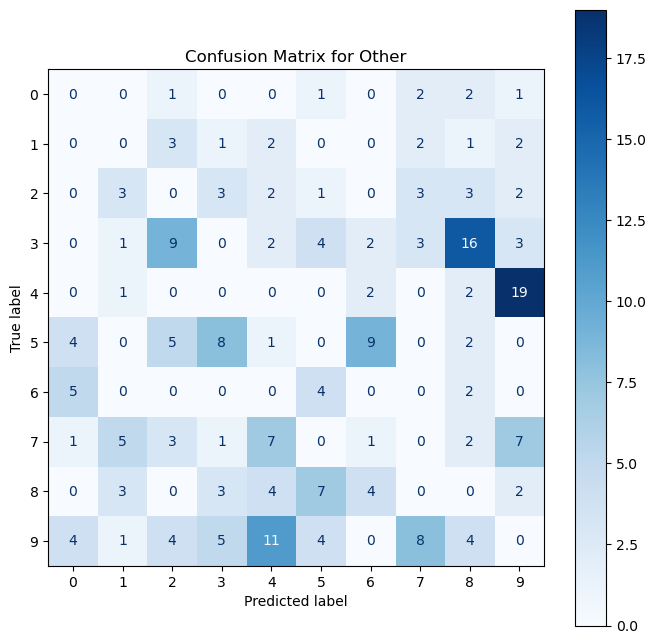

In [8]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

cm_mnist = confusion_matrix(val_target, y_pred_ovo_svc_cpu)
for i in range(10):
    cm_mnist[i][i] = 0

disp_other = ConfusionMatrixDisplay(confusion_matrix=cm_mnist, display_labels=np.arange(10))
fig_other, ax_other = plt.subplots(figsize=(8, 8))
disp_other.plot(cmap=plt.cm.Blues, ax=ax_other)
plt.title("Confusion Matrix for Other")
plt.show()

## confusion matrix 합산

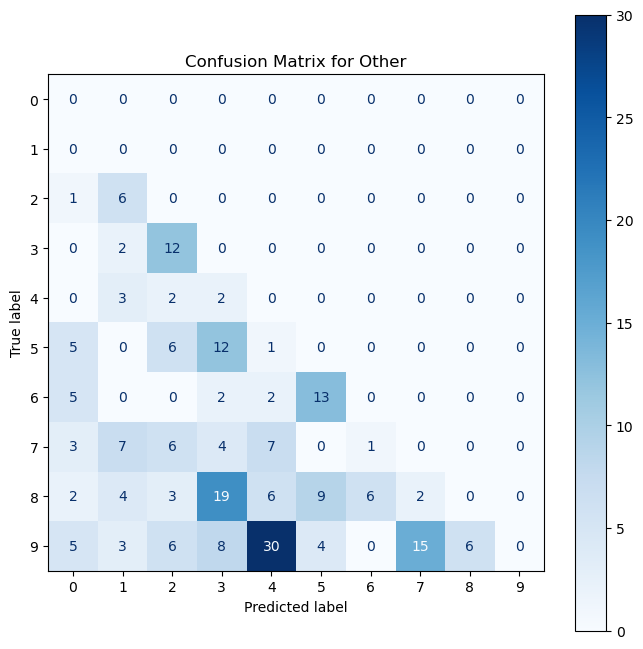

In [9]:
fixed = cm_mnist.copy()
for i in range(10):
    for j in range(i, 10):
        fixed[i][j] += fixed[j][i]
        fixed[j][i] = 0

fixed = fixed.transpose()
disp_other = ConfusionMatrixDisplay(confusion_matrix=fixed, display_labels=np.arange(10))
fig_other, ax_other = plt.subplots(figsize=(8, 8))
disp_other.plot(cmap=plt.cm.Blues, ax=ax_other)
plt.title("Confusion Matrix for Other")
plt.show()

In [10]:
# fixed 매트릭스 안에서 최대값 5개의 요소를 뽑아 (행, 열)로 저장해서 출력
import heapq
indices = heapq.nlargest(10, [(fixed[i][j], (i, j)) for i in range(10) for j in range(10)], key=lambda x: x[0])
print("Top 5 confusion pairs (value, (true label, predicted label)):")
for value, (i, j) in indices:
    if value >= 15:
        print(f"Value: {value}, Label: {i}, Label: {j}")

Top 5 confusion pairs (value, (true label, predicted label)):
Value: 30, Label: 9, Label: 4
Value: 19, Label: 8, Label: 3
Value: 15, Label: 9, Label: 7


In [11]:
import matplotlib as mpl

# EXTRA plot functions for multiple digit instances
def plot_digits(instances, images_per_row=10, **options):
    size = 28
    images_per_row = min(len(instances), images_per_row)
    images = [instance.reshape(size,size) for instance in instances]
    n_rows = (len(instances) - 1) // images_per_row + 1
    row_images = []
    n_empty = n_rows * images_per_row - len(instances)
    images.append(np.zeros((size, size * n_empty)))
    for row in range(n_rows):
        rimages = images[row * images_per_row : (row + 1) * images_per_row]
        row_images.append(np.concatenate(rimages, axis=1))
    image = np.concatenate(row_images, axis=0)
    plt.imshow(image, cmap = mpl.cm.gray, **options)
    plt.axis("off")

In [12]:
def print_digit_confusion(i, j):
    X_train = val_input
    y_train = val_target
    y_train_pred = y_pred_ovo_svc_cpu

    X_33 = X_train[(y_train == i) & (y_train_pred == i)]
    X_35 = X_train[(y_train == i) & (y_train_pred == j)]
    X_53 = X_train[(y_train == j) & (y_train_pred == i)]
    X_55 = X_train[(y_train == j) & (y_train_pred == j)]

    plt.figure(figsize=(8,8))
    plt.subplot(221); plot_digits(X_33[:25], images_per_row=5); plt.title(f'[True] Lable = {i} & Prediction = {i}');
    plt.subplot(222); plot_digits(X_35[:25], images_per_row=5); plt.title(f'[False] Lable = {i} & Prediction = {j}');
    plt.subplot(223); plot_digits(X_53[:25], images_per_row=5); plt.title(f'[False] Lable = {j} & Prediction = {i}');
    plt.subplot(224); plot_digits(X_55[:25], images_per_row=5); plt.title(f'[True] Lable = {j} & Prediction = {j}');

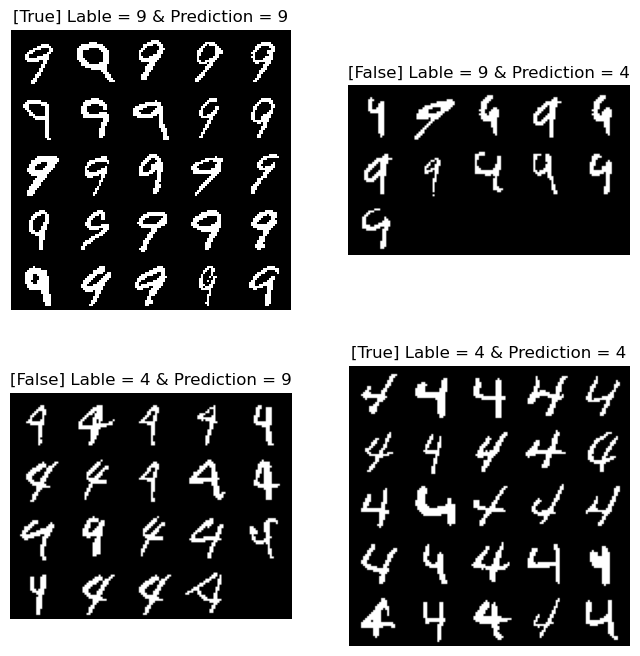

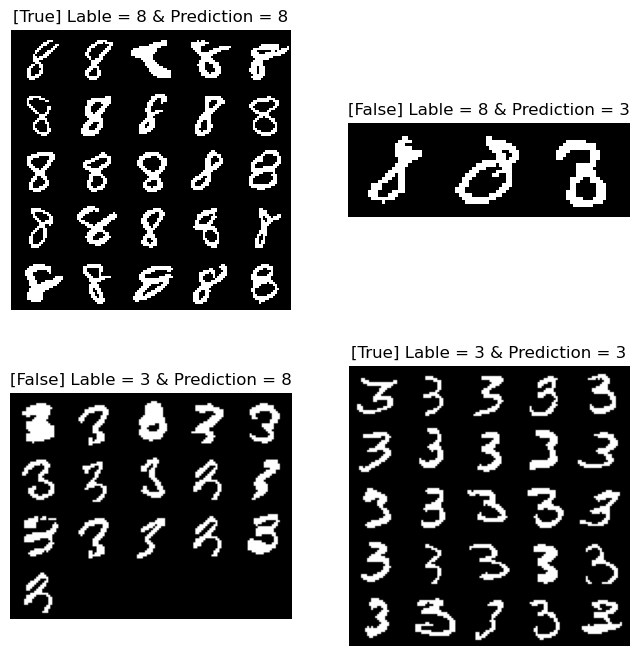

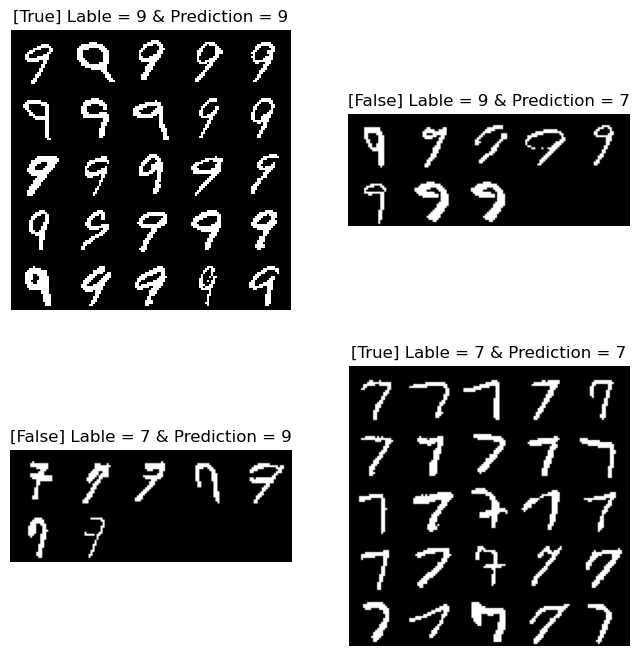

In [13]:
for value, (i, j) in indices:
    if value >= 15:
        print_digit_confusion(i, j)

# 폰트 증강

In [14]:
np.random.shuffle(font_images)

In [15]:
new_train_input = train_input
new_train_target = train_target

##################################################################

to_add_digits = set()

for value, (i, j) in indices:
    if value >= 15:
        to_add_digits.add(i)
        to_add_digits.add(j)
for i in to_add_digits:
    toAdd_fonts  = font_images[font_labels == i][:6000]
    toAdd_labels = np.ones(toAdd_fonts.shape[0]) * i

    new_train_input = np.concatenate((new_train_input, toAdd_fonts), axis=0)
    new_train_target = np.concatenate((new_train_target, toAdd_labels), axis=0)

#################################################################

# for value, (i, j) in indices:
#     toAdd_fonts_i  = font_images[font_labels == i][:6000]
#     toAdd_labels_i = np.ones(toAdd_fonts_i.shape[0]) * i

#     toAdd_fonts_j  = font_images[font_labels == j][:6000]
#     toAdd_labels_j = np.ones(toAdd_fonts_j.shape[0]) * j

#     new_train_input = np.concatenate((new_train_input, toAdd_fonts_i, toAdd_fonts_j), axis=0)
#     new_train_target = np.concatenate((new_train_target, toAdd_labels_i, toAdd_labels_j), axis=0)

In [16]:
if USE_CUML:
    new_train_input_cp = cp.asarray(new_train_input)
    new_train_target_cp = cp.asarray(new_train_target)
    cp.get_default_memory_pool().free_all_blocks()
    
# training
ovo_svc_font_added = OneVsOneClassifier_svc_class
ovo_svc_font_added.fit(new_train_input_cp if USE_CUML else new_train_input, new_train_target_cp if USE_CUML else new_train_target)

OneVsOneClassifier(estimator=SVC())

In [17]:
if USE_CUML:
    del new_train_input_cp
    del new_train_target_cp

In [18]:
# --- 1. 예측 수행 (Predict) ---
y_pred_ovo_svc = ovo_svc_font_added.predict(val_input_cp if USE_CUML else val_input)
del ovo_svc_font_added

new_y_pred_ovo_svc_cpu  = y_pred_ovo_svc.get() if USE_CUML else y_pred_ovo_svc
del y_pred_ovo_svc

results['ovo (SVC) font'] = {
    'Accuracy': sk_accuracy_score(val_target, new_y_pred_ovo_svc_cpu),
    'F1 Score (weighted)': sk_f1_score(val_target, new_y_pred_ovo_svc_cpu, average=average_mode)
}

# --- 4. 결과 출력 ---
print("\n" + "="*50)
if USE_CUML:
    print("     cuML Prediction + Scikit-learn Evaluation")
else:
    print("  sklearn Prediction + Scikit-learn Evaluation")
print(f"    classification by {MY_LABEL}")
print("="*50)

for model_name, scores in results.items():
    print(f"\n--- {model_name} ---")
    print(f"Accuracy:        {scores['Accuracy']:.4f}")
    print(f"F1 Score (wgt):  {scores['F1 Score (weighted)']:.4f}")


     cuML Prediction + Scikit-learn Evaluation
    classification by digit

--- KNN ---
Accuracy:        0.9631
F1 Score (wgt):  0.9630

--- Random Forest ---
Accuracy:        0.9779
F1 Score (wgt):  0.9779

--- ovo (LR) ---
Accuracy:        0.9505
F1 Score (wgt):  0.9505

--- ovo (SVC) ---
Accuracy:        0.9808
F1 Score (wgt):  0.9808

--- ovo (SVC) font ---
Accuracy:        0.9825
F1 Score (wgt):  0.9825


In [19]:
!nvidia-smi

Wed Dec 17 15:21:35 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.65.06              Driver Version: 580.65.06      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2070        Off |   00000000:09:00.0 Off |                  N/A |
| 57%   55C    P2             61W /  175W |    1802MiB /   8192MiB |     92%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# 폰트 증강의 성능 평가

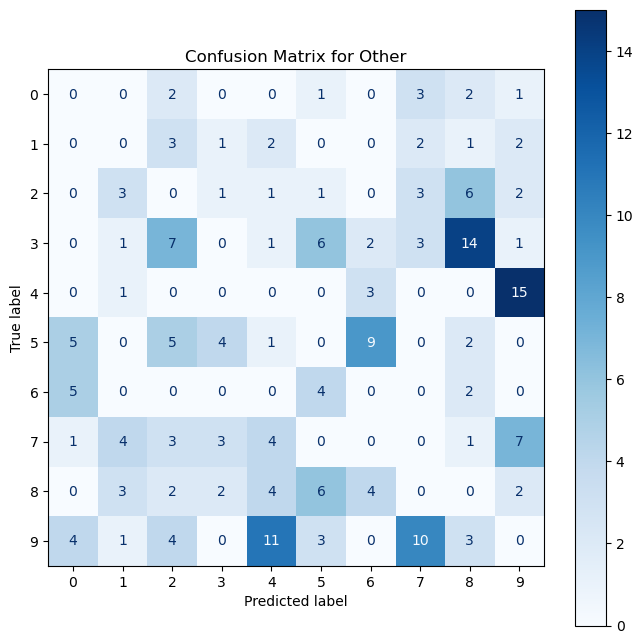

In [20]:
font_added_mnist = confusion_matrix(val_target, new_y_pred_ovo_svc_cpu)
for i in range(10):
    font_added_mnist[i][i] = 0

disp_other = ConfusionMatrixDisplay(confusion_matrix=font_added_mnist, display_labels=np.arange(10))
fig_other, ax_other = plt.subplots(figsize=(8, 8))
disp_other.plot(cmap=plt.cm.Blues, ax=ax_other)
plt.title("Confusion Matrix for Other")
plt.show()

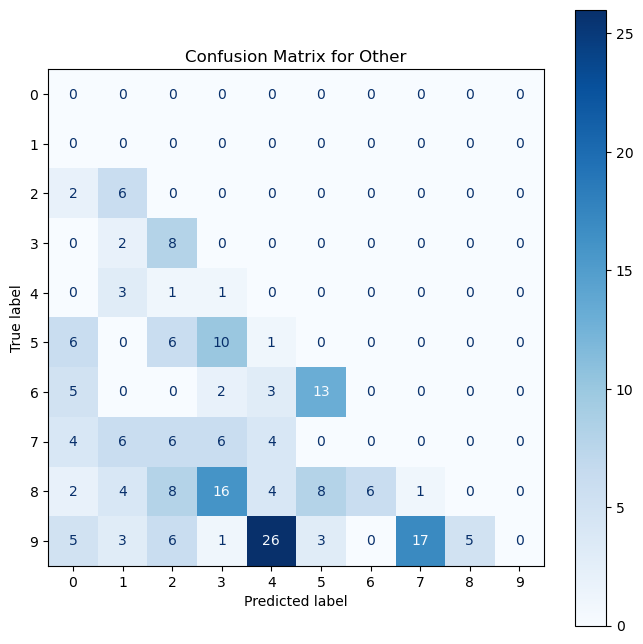

In [21]:
fixed = font_added_mnist.copy()
for i in range(10):
    for j in range(i, 10):
        fixed[i][j] += fixed[j][i]
        fixed[j][i] = 0

fixed = fixed.transpose()
disp_other = ConfusionMatrixDisplay(confusion_matrix=fixed, display_labels=np.arange(10))
fig_other, ax_other = plt.subplots(figsize=(8, 8))
disp_other.plot(cmap=plt.cm.Blues, ax=ax_other)
plt.title("Confusion Matrix for Other")
plt.show()

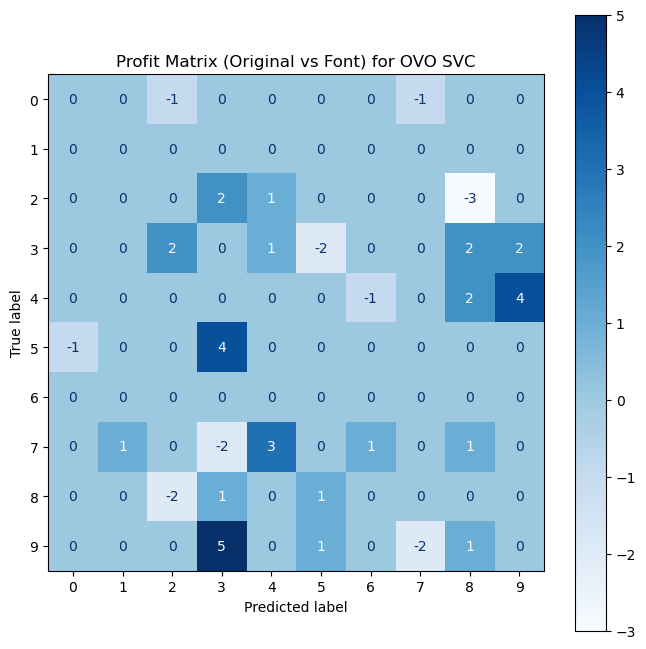

profit: 35 / loss: -15 / total: 20


In [22]:
profit_matrix = cm_mnist - font_added_mnist

disp_other = ConfusionMatrixDisplay(confusion_matrix=profit_matrix, display_labels=np.arange(10))
fig_other, ax_other = plt.subplots(figsize=(8, 8))
disp_other.plot(cmap=plt.cm.Blues, ax=ax_other)
plt.title("Profit Matrix (Original vs Font) for OVO SVC")
plt.show()

profit = 0
loss = 0
for i in range(10):
    for j in range(10):
        if profit_matrix[i][j] > 0:
            profit += profit_matrix[i][j]
        else:
            loss += profit_matrix[i][j]

print(f"profit: {profit} / loss: {loss} / total: {profit + loss}")


In [23]:
# fixed 매트릭스 안에서 최대값 5개의 요소를 뽑아 (행, 열)로 저장해서 출력
import heapq
after_font_indices = heapq.nlargest(10, [(fixed[i][j], (i, j)) for i in range(10) for j in range(10)], key=lambda x: x[0])
print("Top 5 confusion pairs (value, (true label, predicted label)):")
for value, (i, j) in after_font_indices:
    if value >= 15:
        print(f"Value: {value}, Label: {i}, Label: {j}")

Top 5 confusion pairs (value, (true label, predicted label)):
Value: 26, Label: 9, Label: 4
Value: 17, Label: 9, Label: 7
Value: 16, Label: 8, Label: 3


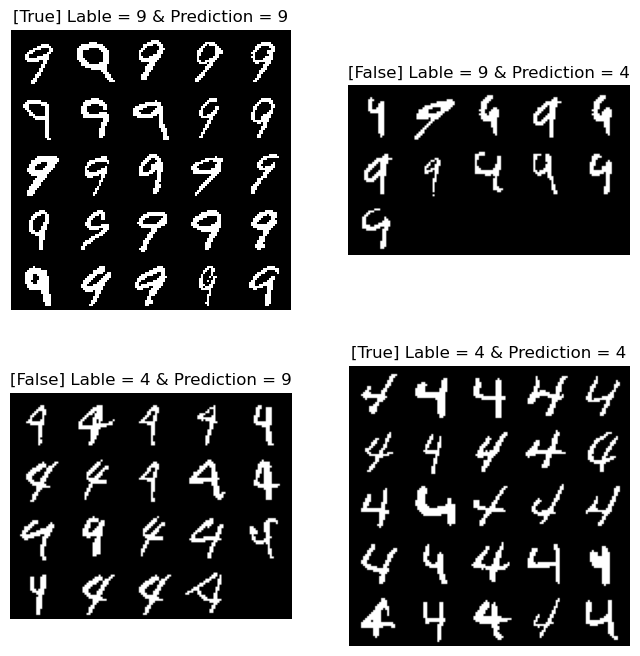

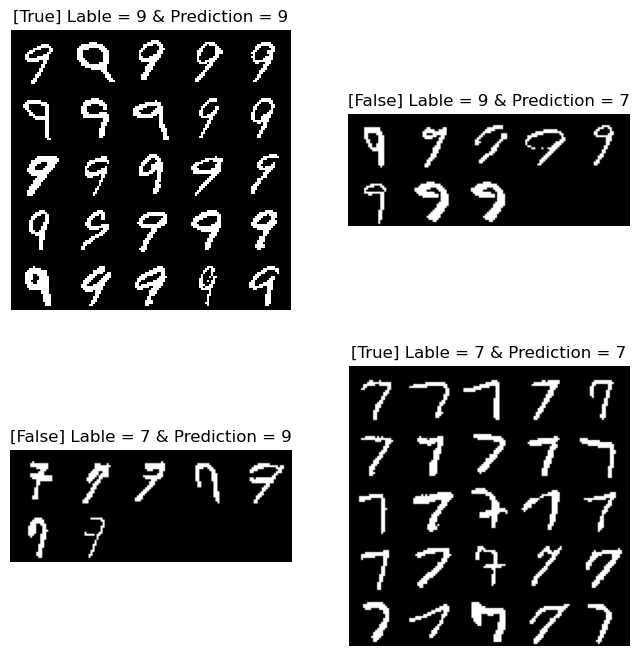

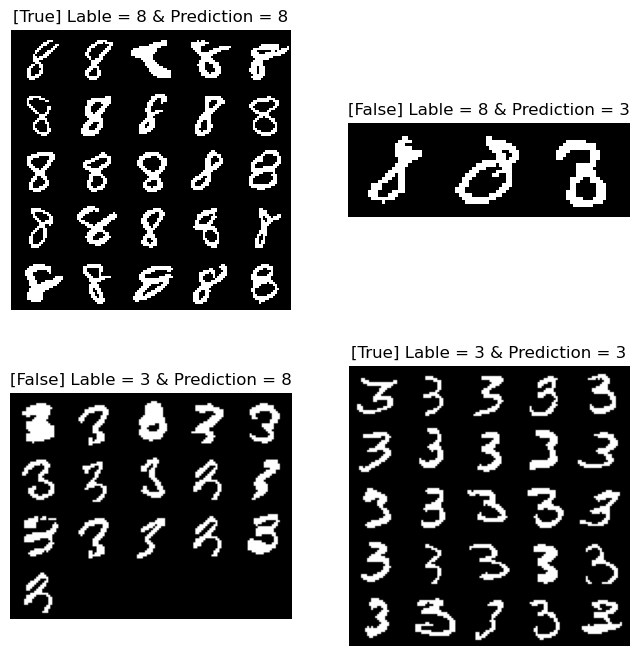

In [24]:
for value, (i, j) in after_font_indices:
    if value >= 15:
        print_digit_confusion(i, j)

# tilt 증강

In [25]:
from scipy.ndimage import rotate
import random

def rotate_image(image):
    # -15도에서 +15도 사이의 무작위 회전을 적용합니다.
    angle = random.uniform(-5, 5)
    # 새로운 영역을 0으로 채우면서(검은색) 이미지를 회전합니다.
    rotated_image = rotate(image, angle, reshape=False, cval=0.0)
    return rotated_image

print("'rotate_image' 증강 함수가 정의되었습니다.")

'rotate_image' 증강 함수가 정의되었습니다.


In [26]:
# 1. 틸트할 클래스 선택 (예: 3과 5)
tilt_classes = set()
for value, (i, j) in after_font_indices:
    if value >= 15:
        tilt_classes.add(i)
        tilt_classes.add(j)
print("틸트할 클래스:", tilt_classes)

# 2. 선택한 클래스에 대해 훈련 데이터 증강
augmented_images = []
augmented_labels = []
for cls in tilt_classes:
    class_images = train_input[train_target == cls][:6000]  # 각 클래스에서 최대 5000개 이미지 선택
    for img in class_images:
        rotated_img = rotate_image(img.reshape(28, 28))  # 이미지 크기에 맞게 reshape
        augmented_images.append(rotated_img.flatten())   # 다시 1D로 변환
        augmented_labels.append(cls)

틸트할 클래스: {3, 4, 7, 8, 9}


(23927, 784)

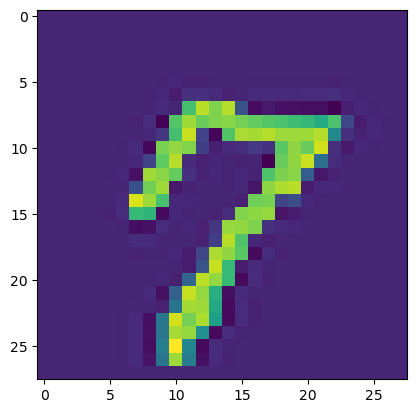

In [27]:
plt.imshow(augmented_images[random.randint(0, len(augmented_images))-1].reshape(28,28))
np.array(augmented_images).shape

In [28]:
tilt_added_train_input  = np.concatenate((new_train_input, augmented_images), axis=0)
tilt_added_train_target = np.concatenate((new_train_target, augmented_labels), axis=0)

print(tilt_added_train_input.shape)
print(tilt_added_train_target.shape)

(101659, 784)
(101659,)


In [29]:
if USE_CUML:
    tilt_added_train_input_cp = cp.asarray(tilt_added_train_input)
    tilt_added_train_target_cp = cp.asarray(tilt_added_train_target)
    cp.get_default_memory_pool().free_all_blocks()

# training
ovo_svc_tilt_added = OneVsOneClassifier_svc_class
ovo_svc_tilt_added.fit(tilt_added_train_input_cp if USE_CUML else tilt_added_train_input, tilt_added_train_target_cp if USE_CUML else tilt_added_train_target)


OneVsOneClassifier(estimator=SVC())

In [30]:
del tilt_added_train_input_cp
del tilt_added_train_target_cp

In [31]:
# --- 1. 예측 수행 (Predict) ---
y_pred_ovo_svc = ovo_svc_tilt_added.predict(val_input_cp if USE_CUML else val_input)
del ovo_svc_tilt_added
font_y_pred_ovo_svc_cpu  = y_pred_ovo_svc.get() if USE_CUML else y_pred_ovo_svc
del y_pred_ovo_svc


results['ovo (SVC) tilted'] = {
    'Accuracy': sk_accuracy_score(val_target, font_y_pred_ovo_svc_cpu),
    'F1 Score (weighted)': sk_f1_score(val_target, font_y_pred_ovo_svc_cpu, average=average_mode)
}

# --- 4. 결과 출력 ---
print("\n" + "="*50)
if USE_CUML:
    print("     cuML Prediction + Scikit-learn Evaluation")
else:
    print("  sklearn Prediction + Scikit-learn Evaluation")
print(f"    classification by {MY_LABEL}")
print("="*50)

for model_name, scores in results.items():
    print(f"\n--- {model_name} ---")
    print(f"Accuracy:        {scores['Accuracy']:.4f}")
    print(f"F1 Score (wgt):  {scores['F1 Score (weighted)']:.4f}")


     cuML Prediction + Scikit-learn Evaluation
    classification by digit

--- KNN ---
Accuracy:        0.9631
F1 Score (wgt):  0.9630

--- Random Forest ---
Accuracy:        0.9779
F1 Score (wgt):  0.9779

--- ovo (LR) ---
Accuracy:        0.9505
F1 Score (wgt):  0.9505

--- ovo (SVC) ---
Accuracy:        0.9808
F1 Score (wgt):  0.9808

--- ovo (SVC) font ---
Accuracy:        0.9825
F1 Score (wgt):  0.9825

--- ovo (SVC) tilted ---
Accuracy:        0.9846
F1 Score (wgt):  0.9846


In [32]:
!nvidia-smi

Wed Dec 17 15:21:51 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.65.06              Driver Version: 580.65.06      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2070        Off |   00000000:09:00.0 Off |                  N/A |
| 58%   55C    P2             61W /  175W |    1890MiB /   8192MiB |     92%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

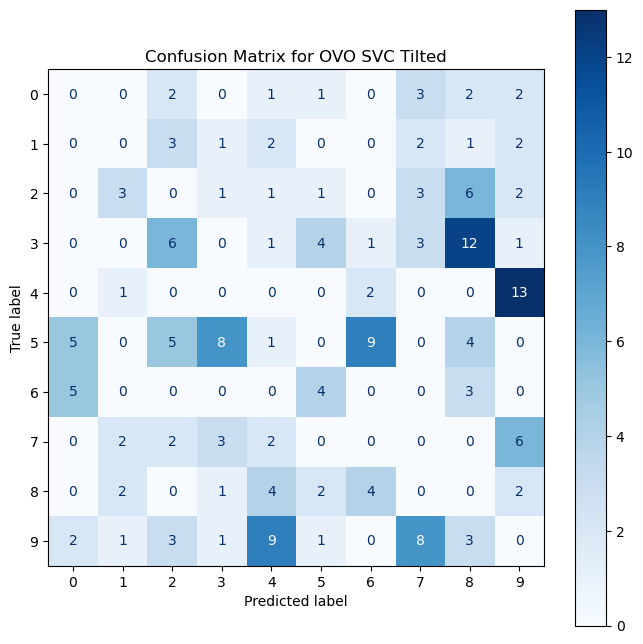

In [33]:
tilted_mnist = confusion_matrix(val_target, font_y_pred_ovo_svc_cpu)
for i in range(10):
    tilted_mnist[i][i] = 0

disp_other = ConfusionMatrixDisplay(confusion_matrix=tilted_mnist, display_labels=np.arange(10))
fig_other, ax_other = plt.subplots(figsize=(8, 8))
disp_other.plot(cmap=plt.cm.Blues, ax=ax_other)
plt.title("Confusion Matrix for OVO SVC Tilted")
plt.show()

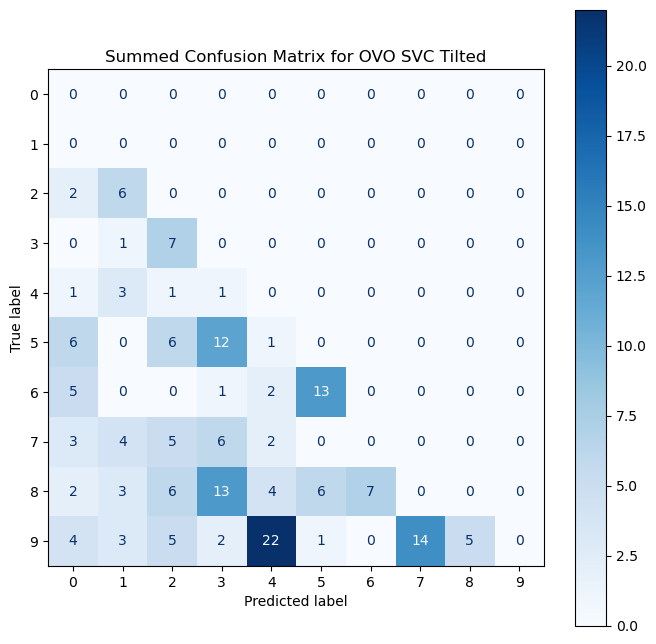

In [34]:
fixed_tilted = tilted_mnist.copy()
for i in range(10):
    for j in range(i, 10):
        fixed_tilted[i][j] += fixed_tilted[j][i]
        fixed_tilted[j][i] = 0

fixed_tilted = fixed_tilted.transpose()
disp_other = ConfusionMatrixDisplay(confusion_matrix=fixed_tilted, display_labels=np.arange(10))
fig_other, ax_other = plt.subplots(figsize=(8, 8))
disp_other.plot(cmap=plt.cm.Blues, ax=ax_other)
plt.title("Summed Confusion Matrix for OVO SVC Tilted")
plt.show()

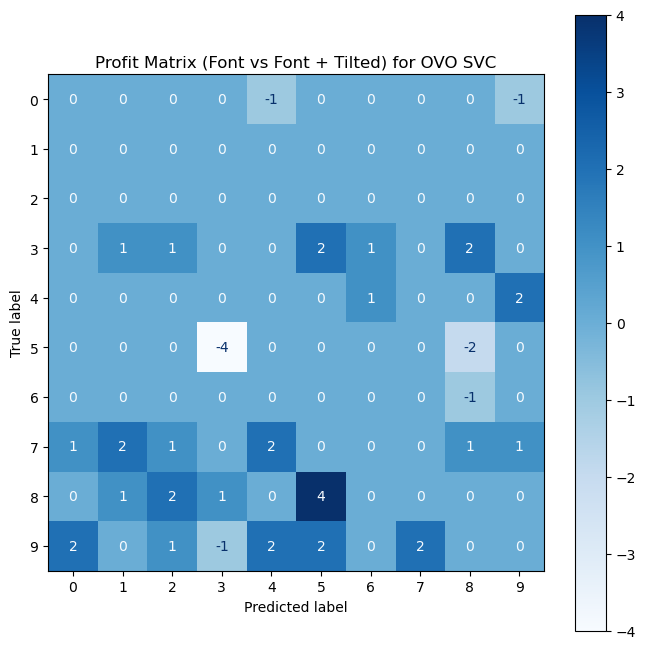

profit: 35 / loss: -10 / total: 25


In [35]:
profit_matrix_tilted = font_added_mnist - tilted_mnist

disp_other = ConfusionMatrixDisplay(confusion_matrix=profit_matrix_tilted, display_labels=np.arange(10))
fig_other, ax_other = plt.subplots(figsize=(8, 8))
disp_other.plot(cmap=plt.cm.Blues, ax=ax_other)
plt.title("Profit Matrix (Font vs Font + Tilted) for OVO SVC")
plt.show()

profit_tilted = 0
loss_tilted = 0
for i in range(10):
    for j in range(10):
        if profit_matrix_tilted[i][j] > 0:
            profit_tilted += profit_matrix_tilted[i][j]
        else:
            loss_tilted += profit_matrix_tilted[i][j]

print(f"profit: {profit_tilted} / loss: {loss_tilted} / total: {profit_tilted + loss_tilted}")

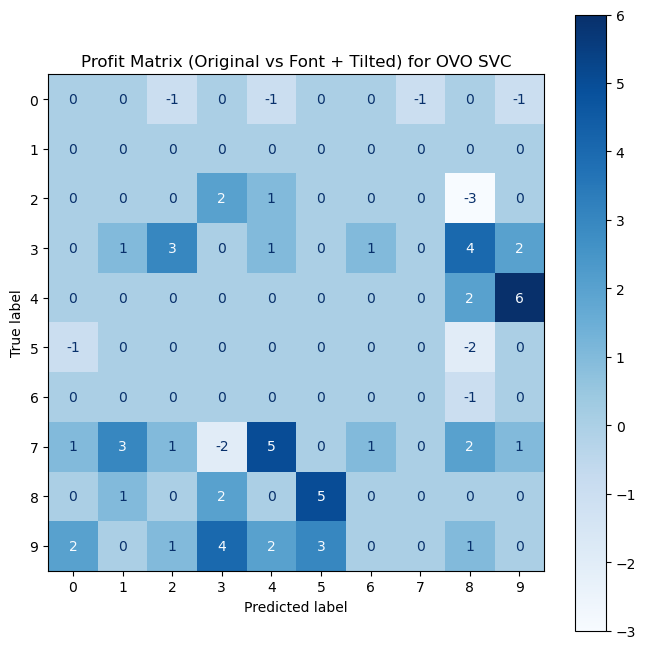

profit: 58 / loss: -13 / total: 45


In [36]:
profit_m_final = cm_mnist - tilted_mnist

disp_other = ConfusionMatrixDisplay(confusion_matrix=profit_m_final, display_labels=np.arange(10))
fig_other, ax_other = plt.subplots(figsize=(8, 8))
disp_other.plot(cmap=plt.cm.Blues, ax=ax_other)
plt.title("Profit Matrix (Original vs Font + Tilted) for OVO SVC")
plt.show()

profit_tilted = 0
loss_tilted = 0
for i in range(10):
    for j in range(10):
        if profit_m_final[i][j] > 0:
            profit_tilted += profit_m_final[i][j]
        else:
            loss_tilted += profit_m_final[i][j]

print(f"profit: {profit_tilted} / loss: {loss_tilted} / total: {profit_tilted + loss_tilted}")

# HOG 추가

In [37]:
# from skimage.feature import hog
# from sklearn.preprocessing import StandardScaler

# # new_train_target
# # new_train_input

# # ===================================================================
# # 2) 개선된 HOG Feature Extract
# #    - MNIST에는 (7,7) cell이 매우 효과적
# # ===================================================================
# def extract_hog_features(images):
#     hog_features = []
#     for img in images:
#         img = img.reshape(28, 28)
#         feat = hog(img,
#                    orientations=9,
#                    pixels_per_cell=(7, 7),
#                    cells_per_block=(2, 2),
#                    block_norm='L2-Hys')
#         hog_features.append(feat)
#     return np.array(hog_features)

# print("Extracting HOG...")
# train_hog = extract_hog_features(new_train_input)
# val_hog   = extract_hog_features(val_input)

# print("HOG shape:", train_hog.shape)


# # ===================================================================
# # 3) FEATURE SCALING (SVM 성능 폭발적으로 증가!)
# # ===================================================================
# scaler = StandardScaler()
# train_hog_scaled = scaler.fit_transform(train_hog)
# val_hog_scaled   = scaler.transform(val_hog)



In [38]:
# # training
# if USE_CUML:
#     train_hog_scaled_cp = cp.asarray(train_hog_scaled)

# ovo_svc_final = OneVsOneClassifier_svc_class
# !nvidia-smi

# ovo_svc_final.fit(train_hog_scaled_cp if USE_CUML else train_hog_scaled, new_train_target)

In [39]:
# if USE_CUML:
#     val_hog_scaled_cp = cp.asarray(val_hog_scaled)

# # --- 1. 예측 수행 (Predict) ---
# preds = ovo_svc_final.predict(val_hog_scaled_cp if USE_CUML else val_hog_scaled)

# preds = cp.asnumpy(preds) if USE_CUML else preds

# results['ovo (SVC) Hog'] = {
#     'Accuracy': sk_accuracy_score(val_target, preds),
#     'F1 Score (weighted)': sk_f1_score(val_target, preds, average=average_mode)
# }

# # --- 4. 결과 출력 ---
# print("\n" + "="*50)
# if USE_CUML:
#     print("     cuML Prediction + Scikit-learn Evaluation")
# else:
#     print("  sklearn Prediction + Scikit-learn Evaluation")
# print(f"    classification by {MY_LABEL}")
# print("="*50)

# for model_name, scores in results.items():
#     print(f"\n--- {model_name} ---")
#     print(f"Accuracy:        {scores['Accuracy']:.4f}")
#     print(f"F1 Score (wgt):  {scores['F1 Score (weighted)']:.4f}")

In [40]:
!nvidia-smi

Wed Dec 17 15:21:53 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.65.06              Driver Version: 580.65.06      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2070        Off |   00000000:09:00.0 Off |                  N/A |
| 58%   52C    P2             61W /  175W |    1584MiB /   8192MiB |      1%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [41]:
# hog_mnist = confusion_matrix(val_target, preds)
# for i in range(10):
#     hog_mnist[i][i] = 0

# disp_other = ConfusionMatrixDisplay(confusion_matrix=hog_mnist, display_labels=np.arange(10))
# fig_other, ax_other = plt.subplots(figsize=(8, 8))
# disp_other.plot(cmap=plt.cm.Blues, ax=ax_other)
# plt.title("Confusion Matrix for OVO SVC HOG")
# plt.show()

In [42]:
# fixed_hog = hog_mnist.copy()
# for i in range(10):
#     for j in range(i, 10):
#         fixed_hog[i][j] += fixed_hog[j][i]
#         fixed_hog[j][i] = 0

# fixed_hog = fixed_hog.transpose()
# disp_other = ConfusionMatrixDisplay(confusion_matrix=fixed_hog, display_labels=np.arange(10))
# fig_other, ax_other = plt.subplots(figsize=(8, 8))
# disp_other.plot(cmap=plt.cm.Blues, ax=ax_other)
# plt.title("Summed Confusion Matrix for OVO SVC HOG")
# plt.show()

In [43]:
# profit_matrix_hog = font_added_mnist - hog_mnist

# disp_other = ConfusionMatrixDisplay(confusion_matrix=profit_matrix_hog, display_labels=np.arange(10))
# fig_other, ax_other = plt.subplots(figsize=(8, 8))
# disp_other.plot(cmap=plt.cm.Blues, ax=ax_other)
# plt.title("Profit Matrix (Original vs HOG) for OVO SVC")
# plt.show()

# profit_hog = 0
# loss_hog = 0
# for i in range(10):
#     for j in range(10):
#         if profit_matrix_hog[i][j] > 0:
#             profit_hog += profit_matrix_hog[i][j]
#         else:
#             loss_hog += profit_matrix_hog[i][j]

# print(f"profit: {profit_hog} / loss: {loss_hog} / total: {profit_hog + loss_hog}")

In [44]:
# del ovo_svc_final
# del val_hog_scaled_cp
# del train_hog_scaled_cp
# del train_input_cp
# del train_target_cp
# !nvidia-smi

# Grid search

In [45]:
def calculate_gamma_scale(X):
    """
    scikit-learn 및 cuML의 gamma='scale' 값을 계산합니다.

    Args:
        X (np.ndarray or cp.ndarray): 훈련 데이터 배열 (샘플 수 x 특징 수).

    Returns:
        tuple: (계산된 gamma 값, 특징 개수, 데이터 전체 분산)
    """
    
    # 1. 특징(Feature) 개수 (열의 개수)
    n_features = X.shape[1]
    
    # 2. 데이터 전체의 분산 (Var(X)) 계산
    # np.var(X)는 배열 X 전체의 전역 분산을 계산합니다.
    X_var = np.var(X)
    
    # 3. gamma='scale' 공식 적용
    # gamma = 1 / (n_features * Var(X))
    if n_features * X_var == 0:
        # 분모가 0인 경우 (특징이 0개이거나 모든 데이터 값이 동일한 경우)
        return float('inf'), n_features, X_var
    
    calculated_gamma = 1.0 / (n_features * X_var)
    
    return calculated_gamma, n_features, X_var

# 함수 실행
calculated_gamma, n_features, X_var = calculate_gamma_scale(tilt_added_train_input)

print("--- Gamma ('scale') 계산 결과 ---")
print(f"1. 특징 개수 (n_features): {n_features}")
print(f"2. 데이터 전체 분산 (Var(X)): {X_var:.6f}")
print(f"3. 계산된 gamma 값: {calculated_gamma:.12f}")
print(f"\n[수식: gamma = 1 / ({n_features} * {X_var:.6f}) = {calculated_gamma:.12f}]")

--- Gamma ('scale') 계산 결과 ---
1. 특징 개수 (n_features): 784
2. 데이터 전체 분산 (Var(X)): 6229.450195
3. 계산된 gamma 값: 0.000000204755

[수식: gamma = 1 / (784 * 6229.450195) = 0.000000204755]


In [46]:
# tilt_added_train_input_cp = cp.asarray(tilt_added_train_input)
# tilt_added_train_target_cp = cp.asarray(tilt_added_train_target)

grid_train_input, a, grid_train_target, b\
      = train_test_split(tilt_added_train_input, tilt_added_train_target, test_size=0.5, random_state=42)


In [47]:
C_values = [1e-2, 1e-1, 1, 1e1, 1e2]
gamma_values = ["scale", float(calculated_gamma), 1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
kernels = ['rbf']
# 'linear'

best_accuracy = 0
best_f1_score = 0
best_C = None
best_gamma = None
best_model = None
best_kernel = None

print(f"C values to test: {C_values}")
print(f"Gamma values to test: {gamma_values}")


C values to test: [0.01, 0.1, 1, 10.0, 100.0]
Gamma values to test: ['scale', 2.0475485484894307e-07, 1e-09, 1e-08, 1e-07, 1e-06, 1e-05]


In [48]:
print("Starting manual grid search...")

if USE_CUML:
    grid_train_input_cp = cp.asarray(grid_train_input)
    grid_train_target_cp = cp.asarray(grid_train_target)

for C in C_values:
    for gamma in gamma_values:
        for kernel in kernels:
            
            print(f"\nTraining with C={C}, gamma={gamma}")

            # Create a new SVC instance for each iteration
            if USE_CUML:
                current_svc_estimator = cu_SVC(
                    # cache_size = 50,
                    kernel=kernel,
                    C=C,
                    gamma=gamma,
                    max_iter=10000,
                    probability=False # probability=True adds significant overhead
                )
                current_ovo_svc = cu_OneVsOneClassifier(current_svc_estimator)
            else:
                current_svc_estimator = sk_SVC(
                    kernel=kernel,
                    C=C,
                    gamma=gamma,
                    max_iter=10000
                )
                current_ovo_svc = sk_OneVsOneClassifier(current_svc_estimator, n_jobs=-1)

            # Ensure val_input and val_target are in NumPy if USE_CUML is false (a
            # Train the model with the tilt-augmented data
            current_ovo_svc.fit(grid_train_input_cp if USE_CUML else grid_train_input, grid_train_target_cp if USE_CUML else grid_train_target)

            # Make predictions on the validation set
            y_pred_ovo_svc_grid = current_ovo_svc.predict(val_input_cp if USE_CUML else val_input)

            # Convert predictions to CPU for evaluation if using CuPy
            y_pred_ovo_svc_grid_cpu = y_pred_ovo_svc_grid.get() if USE_CUML else y_pred_ovo_svc_grid
            # Evaluate performance
            current_accuracy = sk_accuracy_score(val_target, y_pred_ovo_svc_grid_cpu)
            current_f1_score = sk_f1_score(val_target, y_pred_ovo_svc_grid_cpu, average=average_mode)

            print(f"  Accuracy: {current_accuracy:.4f}")
            print(f"  F1 Score (weighted): {current_f1_score:.4f}")
            # Check if this model is better than the current best
            if current_accuracy > best_accuracy:
                best_accuracy = current_accuracy
                best_f1_score = current_f1_score
                best_C = C
                best_gamma = gamma
                # best_model = current_ovo_svc # Store the best performing model
            del current_ovo_svc
            del y_pred_ovo_svc_grid
            # del tilt_added_grid_train_input_cp
            # del tilt_added_grid_train_target_cp
            cp.get_default_memory_pool().free_all_blocks() if USE_CUML else None
            gc.collect()

print("\nGrid search complete.")
print("="*50)
print(f"Best C: {best_C}")
print(f"Best Gamma: {best_gamma}")
print(f"Best Accuracy: {best_accuracy:.4f}")
print(f"Best F1 Score (weighted): {best_f1_score:.4f}")
print("="*50)

# Add the best result to the results dictionary for comparison
results['ovo (SVC) 1st Grid Search Best'] = {
    'Accuracy': best_accuracy,
    'F1 Score (weighted)': best_f1_score
}

print("\nUpdated results dictionary:")
for model_name, scores in results.items():
    print(f"\n--- {model_name} ---")
    print(f"Accuracy:        {scores['Accuracy']:.4f}")
    print(f"F1 Score (wgt):  {scores['F1 Score (weighted)']:.4f}")


Starting manual grid search...

Training with C=0.01, gamma=scale
  Accuracy: 0.7923
  F1 Score (weighted): 0.7746

Training with C=0.01, gamma=2.0475485484894307e-07
  Accuracy: 0.7909
  F1 Score (weighted): 0.7727

Training with C=0.01, gamma=1e-09
  Accuracy: 0.1022
  F1 Score (weighted): 0.0190

Training with C=0.01, gamma=1e-08
  Accuracy: 0.3399
  F1 Score (weighted): 0.2045

Training with C=0.01, gamma=1e-07
  Accuracy: 0.7725
  F1 Score (weighted): 0.7514

Training with C=0.01, gamma=1e-06
  Accuracy: 0.1841
  F1 Score (weighted): 0.1165

Training with C=0.01, gamma=1e-05
  Accuracy: 0.1022
  F1 Score (weighted): 0.0190

Training with C=0.1, gamma=scale
  Accuracy: 0.9373
  F1 Score (weighted): 0.9374

Training with C=0.1, gamma=2.0475485484894307e-07
  Accuracy: 0.9379
  F1 Score (weighted): 0.9379

Training with C=0.1, gamma=1e-09
  Accuracy: 0.3554
  F1 Score (weighted): 0.2215

Training with C=0.1, gamma=1e-08
  Accuracy: 0.8147
  F1 Score (weighted): 0.8085

Training with 

In [49]:
# C_values = [2, 4, 6, 8, 10, 12, 14, 16, 18]
# gamma_values = [1e-8, 3e-8, 5e-8, 7e-8, 9e-8, 1e-7, 3e-7, 5e-7, 7e-7, 9e-7]
# kernels = ['rbf']
# # 'linear'

# best_accuracy = 0
# best_f1_score = 0
# best_C = None
# best_gamma = None
# best_model = None
# best_kernel = None

# print(f"C values to test: {C_values}")
# print(f"Gamma values to test: {gamma_values}")


In [50]:
# print("Starting 2nd manual grid search...")

# for C in C_values:
#     for gamma in gamma_values:
#         for kernel in kernels:
            
#             print(f"\nTraining with C={C}, gamma={gamma}")

#             # Create a new SVC instance for each iteration
#             if USE_CUML:
#                 current_svc_estimator = cu_SVC(
#                     # cache_size = 50,
#                     kernel=kernel,
#                     C=C,
#                     gamma=gamma,
#                     max_iter=10000,
#                     probability=False # probability=True adds significant overhead
#                 )
#                 current_ovo_svc = cu_OneVsOneClassifier(current_svc_estimator)
#             else:
#                 current_svc_estimator = sk_SVC(
#                     kernel=kernel,
#                     C=C,
#                     gamma=gamma,
#                     max_iter=10000
#                 )
#                 current_ovo_svc = sk_OneVsOneClassifier(current_svc_estimator, n_jobs=-1)

#             # Ensure val_input and val_target are in NumPy if USE_CUML is false (a
#             # Train the model with the tilt-augmented data
#             current_ovo_svc.fit(grid_train_input_cp if USE_CUML else grid_train_input, grid_train_target_cp if USE_CUML else grid_train_target)

#             # Make predictions on the validation set
#             y_pred_ovo_svc_grid = current_ovo_svc.predict(val_input_cp if USE_CUML else val_input)

#             # Convert predictions to CPU for evaluation if using CuPy
#             y_pred_ovo_svc_grid_cpu = y_pred_ovo_svc_grid.get() if USE_CUML else y_pred_ovo_svc_grid
#             # Evaluate performance
#             current_accuracy = sk_accuracy_score(val_target, y_pred_ovo_svc_grid_cpu)
#             current_f1_score = sk_f1_score(val_target, y_pred_ovo_svc_grid_cpu, average=average_mode)

#             print(f"  Accuracy: {current_accuracy:.4f}")
#             print(f"  F1 Score (weighted): {current_f1_score:.4f}")
#             # Check if this model is better than the current best
#             if current_accuracy > best_accuracy:
#                 best_accuracy = current_accuracy
#                 best_f1_score = current_f1_score
#                 best_C = C
#                 best_gamma = gamma
#                 # best_model = current_ovo_svc # Store the best performing model
#             del current_ovo_svc
#             del y_pred_ovo_svc_grid
#             # del tilt_added_grid_train_input_cp
#             # del tilt_added_grid_train_target_cp
#             cp.get_default_memory_pool().free_all_blocks() if USE_CUML else None
#             gc.collect()

# print("\nGrid search complete.")
# print("="*50)
# print(f"Best C: {best_C}")
# print(f"Best Gamma: {best_gamma}")
# print(f"Best Accuracy: {best_accuracy:.4f}")
# print(f"Best F1 Score (weighted): {best_f1_score:.4f}")
# print("="*50)

# # Add the best result to the results dictionary for comparison
# results['ovo (SVC) 2nd Grid Search Best'] = {
#     'Accuracy': best_accuracy,
#     'F1 Score (weighted)': best_f1_score
# }

# print("\nUpdated results dictionary:")
# for model_name, scores in results.items():
#     print(f"\n--- {model_name} ---")
#     print(f"Accuracy:        {scores['Accuracy']:.4f}")
#     print(f"F1 Score (wgt):  {scores['F1 Score (weighted)']:.4f}")


# result

In [51]:
# Grid search complete.
# ==================================================
# Best C: 5
# Best Gamma: 3e-07
# Best Accuracy: 0.9828
# Best F1 Score (weighted): 0.9827

In [52]:
# tilt_added_train_input_cp = cp.asarray(tilt_added_train_input)
# tilt_added_train_target_cp = cp.asarray(tilt_added_train_target)

# if USE_CUML:
#     current_svc_estimator = cu_SVC(
#         kernel="rbf",
#         C=best_C,
#         gamma=best_gamma,
#         max_iter=10000,
#         probability=False # probability=True adds significant overhead
#     )
#     final_ovo_svc = cu_OneVsOneClassifier(current_svc_estimator)
# else:
#     current_svc_estimator = sk_SVC(
#         kernel="rbf",
#         C=best_C,
#         gamma=best_gamma,
#         max_iter=10000
#     )
#     final_ovo_svc = sk_OneVsOneClassifier(current_svc_estimator, n_jobs=-1)

# final_ovo_svc.fit(tilt_added_train_input_cp if USE_CUML else tilt_added_train_input, tilt_added_train_target_cp if USE_CUML else tilt_added_train_target)
# # --- 1. 예측 수행 (Predict) ---
# final_preds = final_ovo_svc.predict(val_input_cp if USE_CUML else val_input)
# final_preds_cpu = final_preds.get() if USE_CUML else final_preds
# results['ovo (SVC) Final Model'] = {
#     'Accuracy': sk_accuracy_score(val_target, final_preds_cpu),
#     'F1 Score (weighted)': sk_f1_score(val_target, final_preds_cpu, average=average_mode)
# }
# # --- 4. 결과 출력 ---
# print("\n" + "="*50)
# if USE_CUML:
#     print("     cuML Prediction + Scikit-learn Evaluation")
# else:
#     print("  sklearn Prediction + Scikit-learn Evaluation")

# print(f"    classification by {MY_LABEL}")
# print("="*50)
# for model_name, scores in results.items():
#     print(f"\n--- {model_name} ---")
#     print(f"Accuracy:        {scores['Accuracy']:.4f}")
#     print(f"F1 Score (wgt):  {scores['F1 Score (weighted)']:.4f}")

# del tilt_added_train_input_cp
# del tilt_added_train_target_cp
    

# vram 절약 cross val

In [53]:
import cupy as cp
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.metrics import accuracy_score
import time

def perform_manual_cv_vram_safe(C, gamma, X_data_np, y_data_np, n_splits=5, random_state=42):
    # 1. CPU에서 분할 인덱스 생성
    cv_splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    scores = []
    rng = np.random.default_rng(random_state)
    
    # 2. 수동 CV 루프 실행
    for train_index, test_index in cv_splitter.split(X_data_np, y_data_np):
        
        # CPU 메모리에서 훈련/테스트 데이터 분할 (NumPy)
        X_train_np, X_test_np = X_data_np[train_index], X_data_np[test_index]
        y_train_np, y_test_np = y_data_np[train_index], y_data_np[test_index]

        indices = np.arange(X_train_np.shape[0])
        rng.shuffle(indices) # 인덱스를 섞음

        X_train_np = X_train_np[indices]
        y_train_np = y_train_np[indices]

        # 3. 데이터 축소 (VRAM 절약 목적)
        X_train_np = X_train_np[:10000]
        y_train_np = y_train_np[:10000]

        
        cp.cuda.Stream.null.synchronize()
        cp.get_default_memory_pool().free_all_blocks()
        
        # --- VRAM 절약 핵심 ---
        if USE_CUML:
            current_svc_estimator = cu_SVC(
                cache_size = 1024,
                kernel='rbf',
                C=C,
                gamma=gamma,
                max_iter=10000,
                probability=False # probability=True adds significant overhead
            )
            current_ovo_svc = cu_OneVsOneClassifier(current_svc_estimator)
        else:
            current_svc_estimator = sk_SVC(
                kernel='rbf',
                C=C,
                gamma=gamma,
                max_iter=10000
            )
            current_ovo_svc = sk_OneVsOneClassifier(current_svc_estimator, n_jobs=-1)
                
        # 3. 훈련 시점에만 CuPy 배열 생성 (GPU로 전송)
        if USE_CUML:
            X_train_cp = cp.asarray(X_train_np, dtype=cp.float32)
            y_train_cp = cp.asarray(y_train_np, dtype=cp.int32)
        current_ovo_svc.fit(X_train_cp if USE_CUML else X_train_np, y_train_cp if USE_CUML else y_train_np)
        
        # 4. 훈련 데이터는 더 이상 필요 없으므로 메모리에서 해제
        if USE_CUML:
            del X_train_cp
            del y_train_cp
            cp.cuda.Stream.null.synchronize()
            cp.get_default_memory_pool().free_all_blocks() # 훈련 데이터 잔여분 정리
        
            # 5. 예측 시점에만 CuPy 배열 생성 및 예측 수행
            X_test_cp = cp.asarray(X_test_np, dtype=cp.float32)

        y_pred = current_ovo_svc.predict(X_test_cp if USE_CUML else X_test_np)
        
        if USE_CUML:
            # 6. 예측에 사용된 테스트 입력 데이터 해제
            del X_test_cp
            del current_ovo_svc

            # 7. 평가를 위해 CPU로 가져와서 점수 계산
            y_pred_cpu = y_pred.get() if USE_CUML else y_pred
            del y_pred
        
        score = accuracy_score(y_test_np, y_pred_cpu) # y_test_np는 이미 CPU에 있음
        scores.append(score)
        
        # (선택 사항) CuPy의 가비지 컬렉션을 명시적으로 실행하여 VRAM 즉시 확보
        gc.collect()
        if USE_CUML:
            cp.cuda.Stream.null.synchronize()
            cp.get_default_memory_pool().free_all_blocks()

    return np.mean(scores)

In [54]:
# --- 데이터 준비 (최초 1회 실행) ---
# Grid Search 시작 전, NumPy 버전 데이터를 준비합니다. 
# (tilt_added_train_input_cp의 get() 메서드를 사용하여 CPU로 변환)

# --- (이전의 C_values, gamma_values, kernels 정의는 그대로 사용) ---

best_score = 0
best_params = {}
C_values = [2, 4, 6, 8, 10, 12, 14, 16, 18]
gamma_values = [1e-8, 3e-8, 5e-8, 7e-8, 9e-8, 1e-7, 3e-7, 5e-7, 7e-7, 9e-7]
kernels = ['rbf']
# 'linear'

best_accuracy = 0
best_f1_score = 0
best_C = None
best_gamma = None
best_model = None
best_kernel = None

print(f"C values to test: {C_values}")
print(f"Gamma values to test: {gamma_values}")

print("--- VRAM 절약 모드 GPU Grid Search 시작 ---")

for kernel in kernels:
    current_gamma_values = gamma_values if kernel == 'rbf' else ['scale'] 

    for C in C_values:
        for gamma in current_gamma_values:
            # 2. 함수를 사용하여 CV 점수 계산 (VRAM 절약 모드 실행)
            start_time = time.time()
            mean_cv_accuracy = perform_manual_cv_vram_safe(
                C,
                gamma,
                mnist_images,
                mnist_labels,
            )
            elapsed_time = time.time() - start_time
            
            # 3. 결과 출력 및 최적 모델 업데이트
            print(f"-> Mean CV Accuracy: {mean_cv_accuracy:.4f} (Time: {elapsed_time:.2f}s, C={C}, gamma={gamma})")

            if mean_cv_accuracy > best_score:
                best_score = mean_cv_accuracy
                best_params = {'C': C, 'gamma': gamma, 'kernel': kernel}
                
# --- 최종 결과 출력 ---
print("\n" + "="*50)
print(f"Best Accuracy: {best_score:.4f}")
print(f"Best Parameters: {best_params}")

C values to test: [2, 4, 6, 8, 10, 12, 14, 16, 18]
Gamma values to test: [1e-08, 3e-08, 5e-08, 7e-08, 9e-08, 1e-07, 3e-07, 5e-07, 7e-07, 9e-07]
--- VRAM 절약 모드 GPU Grid Search 시작 ---
-> Mean CV Accuracy: 0.9136 (Time: 9.94s, C=2, gamma=1e-08)
-> Mean CV Accuracy: 0.9309 (Time: 9.71s, C=2, gamma=3e-08)
-> Mean CV Accuracy: 0.9411 (Time: 9.66s, C=2, gamma=5e-08)
-> Mean CV Accuracy: 0.9480 (Time: 9.64s, C=2, gamma=7e-08)
-> Mean CV Accuracy: 0.9526 (Time: 9.65s, C=2, gamma=9e-08)
-> Mean CV Accuracy: 0.9549 (Time: 9.64s, C=2, gamma=1e-07)
-> Mean CV Accuracy: 0.9677 (Time: 10.07s, C=2, gamma=3e-07)
-> Mean CV Accuracy: 0.9657 (Time: 10.94s, C=2, gamma=5e-07)
-> Mean CV Accuracy: 0.9570 (Time: 12.74s, C=2, gamma=7e-07)
-> Mean CV Accuracy: 0.9328 (Time: 14.12s, C=2, gamma=9e-07)
-> Mean CV Accuracy: 0.9211 (Time: 9.71s, C=4, gamma=1e-08)
-> Mean CV Accuracy: 0.9376 (Time: 9.56s, C=4, gamma=3e-08)
-> Mean CV Accuracy: 0.9468 (Time: 9.55s, C=4, gamma=5e-08)
-> Mean CV Accuracy: 0.9528 (Time:

In [55]:
if USE_CUML:
    tilt_added_train_input_cp = cp.asarray(tilt_added_train_input)
    tilt_added_train_target_cp = cp.asarray(tilt_added_train_target)

if USE_CUML:
    svc_gpu = cu_SVC(
        kernel="rbf",
        C=best_params['C'],
        gamma=best_params['gamma'],
        probability=False # probability=True adds significant overhead
    )
    final_ovo_svc_gpu = cu_OneVsOneClassifier(svc_gpu)
    final_ovo_svc_gpu.fit(tilt_added_train_input_cp, tilt_added_train_target_cp) if USE_CUML else None
    # --- 1. 예측 수행 (Predict) ---
    final_preds = final_ovo_svc_gpu.predict(val_input_cp)
    final_preds_cpu = final_preds.get()
    results['ovo (SVC) Final Model GPU'] = {
        'Accuracy': sk_accuracy_score(val_target, final_preds_cpu),
        'F1 Score (weighted)': sk_f1_score(val_target, final_preds_cpu, average=average_mode)
    }
del tilt_added_train_input_cp
del tilt_added_train_target_cp
print("gpu done")

from sklearn.multiclass import OneVsOneClassifier as sk_OneVsOneClassifier
from sklearn.svm import SVC as sk_SVC

svc_cpu = sk_SVC(
    kernel="rbf",
    C=best_params['C'],
    gamma=best_params['gamma'],
)
final_ovo_svc_cpu = sk_OneVsOneClassifier(svc_cpu, n_jobs=-1)
final_ovo_svc_cpu.fit(tilt_added_train_input, tilt_added_train_target)

final_preds_2 = final_ovo_svc_cpu.predict(val_input)
results['ovo (SVC) Final Model CPU'] = {
    'Accuracy': sk_accuracy_score(val_target, final_preds_2),
    'F1 Score (weighted)': sk_f1_score(val_target, final_preds_2, average=average_mode)
}
print("cpu done")

# --- 4. 결과 출력 ---
print("\n" + "="*50)
if USE_CUML:
    print("     cuML Prediction + Scikit-learn Evaluation")
else:
    print("  sklearn Prediction + Scikit-learn Evaluation")

print(f"    classification by {MY_LABEL}")
print("="*50)
for model_name, scores in results.items():
    print(f"\n--- {model_name} ---")
    print(f"Accuracy:        {scores['Accuracy']:.4f}")
    print(f"F1 Score (wgt):  {scores['F1 Score (weighted)']:.4f}")

    

gpu done
cpu done

     cuML Prediction + Scikit-learn Evaluation
    classification by digit

--- KNN ---
Accuracy:        0.9631
F1 Score (wgt):  0.9630

--- Random Forest ---
Accuracy:        0.9779
F1 Score (wgt):  0.9779

--- ovo (LR) ---
Accuracy:        0.9505
F1 Score (wgt):  0.9505

--- ovo (SVC) ---
Accuracy:        0.9808
F1 Score (wgt):  0.9808

--- ovo (SVC) font ---
Accuracy:        0.9825
F1 Score (wgt):  0.9825

--- ovo (SVC) tilted ---
Accuracy:        0.9846
F1 Score (wgt):  0.9846

--- ovo (SVC) 1st Grid Search Best ---
Accuracy:        0.9818
F1 Score (wgt):  0.9818

--- ovo (SVC) Final Model GPU ---
Accuracy:        0.9882
F1 Score (wgt):  0.9882

--- ovo (SVC) Final Model CPU ---
Accuracy:        0.9882
F1 Score (wgt):  0.9882


In [56]:
import joblib

model_bundle = {
    'ovo_model': final_ovo_svc_gpu,
    'C': best_params['C'],
    'gamma': best_params['gamma'], # 👈 gamma 값을 명시적으로 저장
}

joblib.dump(model_bundle, 'final_svc_bundle_cuml.joblib')
print("✅ cuML 모델과 필수 하이퍼파라미터가 안전하게 저장되었습니다.")

model_bundle = {
    'ovo_model': final_ovo_svc_cpu,
    'C': best_params['C'],
    'gamma': best_params['gamma'], # 👈 gamma 값을 명시적으로 저장
}

joblib.dump(model_bundle, 'final_svc_bundle_sklearn.joblib')
print("✅ scikit-learn 모델과 필수 하이퍼파라미터가 안전하게 저장되었습니다.")

# # --- 로드 및 재설정 ---
# # 로드 후, 반드시 gamma를 수동으로 강제 적용해야 합니다.
# loaded_bundle = joblib.load('final_cuml_svc_bundle.joblib')
# loaded_ovo_model = loaded_bundle['ovo_model']
# loaded_gamma = loaded_bundle['gamma']

# # 🚨 gamma 값 강제 재설정 (핵심)
# if hasattr(loaded_ovo_model, 'estimators_'):
#     for estimator in loaded_ovo_model.estimators_:
#         estimator.gamma = loaded_gamma

✅ cuML 모델과 필수 하이퍼파라미터가 안전하게 저장되었습니다.
✅ scikit-learn 모델과 필수 하이퍼파라미터가 안전하게 저장되었습니다.
